In [1]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
import os
from skimage.metrics import peak_signal_noise_ratio, structural_similarity


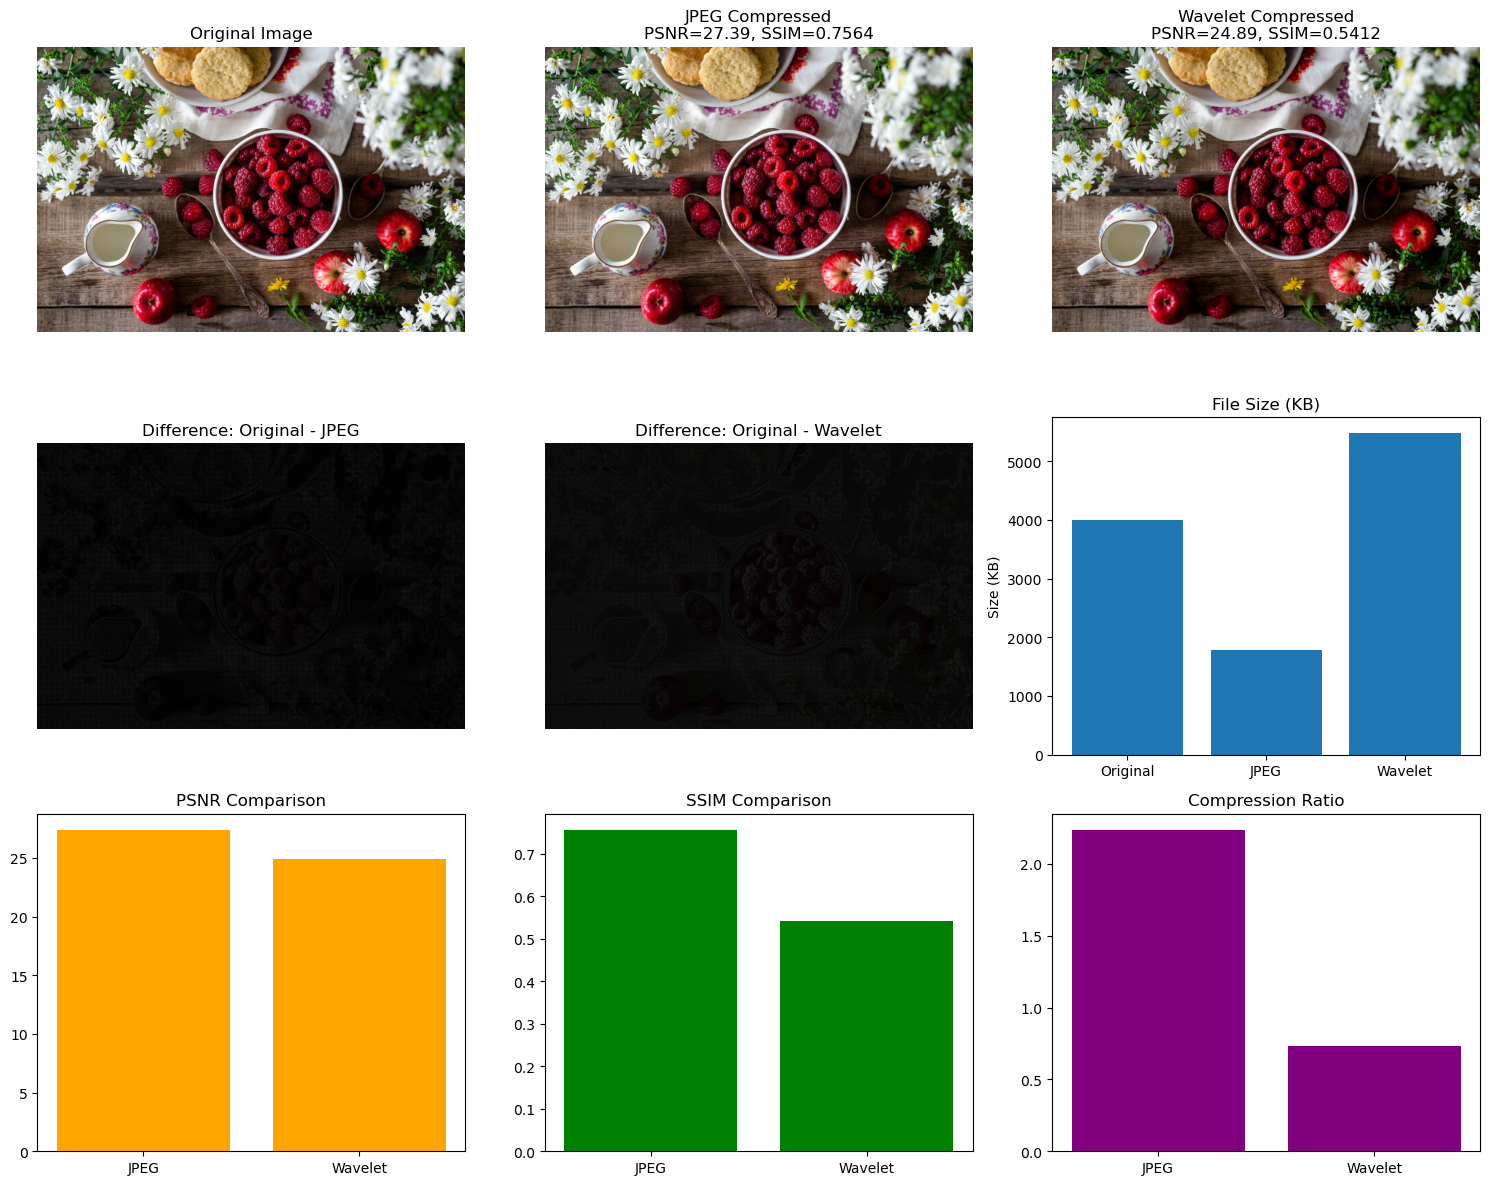

Original Size: 3998.92 KB
JPEG Size: 1788.77 KB | PSNR: 27.39 | SSIM: 0.7564 | CR: 2.24
Wavelet Size: 5475.64 KB | PSNR: 24.89 | SSIM: 0.5412 | CR: 0.73


In [17]:
import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
import os
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
# -------------------- Load Image --------------------
image_path = r"C:\Users\zainu\Downloads\test.jpg"
image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Image not found at {image_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
original_size = os.path.getsize(image_path) / 1024  # in KB

# -------------------- JPEG Compression --------------------
def jpeg_compress(img, quality=25, out_path='compressed_jpeg.jpg'):
    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
    _, encimg = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR), encode_param)
    with open(out_path, 'wb') as f:
        f.write(encimg.tobytes())
    compressed_img = cv2.imread(out_path)
    compressed_img = cv2.cvtColor(compressed_img, cv2.COLOR_BGR2RGB)
    size = os.path.getsize(out_path) / 1024
    return compressed_img, size

# -------------------- Wavelet Compression --------------------
def wavelet_compress(img, wavelet='haar', level=2, out_path='compressed_wavelet.jpg'):
    coeffs = []
    for c in cv2.split(img):
        coeff = pywt.wavedec2(c, wavelet=wavelet, level=level)
        arr, coeff_slices = pywt.coeffs_to_array(coeff)
        arr = pywt.threshold(arr, 30, mode='soft')
        coeff_thresh = pywt.array_to_coeffs(arr, coeff_slices, output_format='wavedec2')
        coeffs.append(pywt.waverec2(coeff_thresh, wavelet=wavelet))

    wavelet_img = np.stack(coeffs, axis=2)
    wavelet_img = np.clip(wavelet_img, 0, 255).astype(np.uint8)
    cv2.imwrite(out_path, cv2.cvtColor(wavelet_img, cv2.COLOR_RGB2BGR))
    size = os.path.getsize(out_path) / 1024
    return wavelet_img, size

# -------------------- Compression --------------------
jpeg_img, jpeg_size = jpeg_compress(image)
wavelet_img, wavelet_size = wavelet_compress(image)

# Resize wavelet image if shape mismatch
if wavelet_img.shape != image.shape:
    wavelet_img = cv2.resize(wavelet_img, (image.shape[1], image.shape[0]))

# -------------------- Metrics --------------------
def get_metrics(original, compressed):
    psnr = peak_signal_noise_ratio(original, compressed)
    ssim = structural_similarity(original, compressed, channel_axis=2)
    return psnr, ssim

jpeg_psnr, jpeg_ssim = get_metrics(image, jpeg_img)
wavelet_psnr, wavelet_ssim = get_metrics(image, wavelet_img)

jpeg_cr = original_size / jpeg_size
wavelet_cr = original_size / wavelet_size

# -------------------- Plots --------------------
fig, axs = plt.subplots(3, 3, figsize=(15, 12))

axs[0, 0].imshow(image)
axs[0, 0].set_title("Original Image")
axs[0, 0].axis("off")

axs[0, 1].imshow(jpeg_img)
axs[0, 1].set_title(f"JPEG Compressed\nPSNR={jpeg_psnr:.2f}, SSIM={jpeg_ssim:.4f}")
axs[0, 1].axis("off")

axs[0, 2].imshow(wavelet_img)
axs[0, 2].set_title(f"Wavelet Compressed\nPSNR={wavelet_psnr:.2f}, SSIM={wavelet_ssim:.4f}")
axs[0, 2].axis("off")

# Difference images
diff_jpeg = cv2.absdiff(image, jpeg_img)
diff_wavelet = cv2.absdiff(image, wavelet_img)

axs[1, 0].imshow(diff_jpeg)
axs[1, 0].set_title("Difference: Original - JPEG")
axs[1, 0].axis("off")

axs[1, 1].imshow(diff_wavelet)
axs[1, 1].set_title("Difference: Original - Wavelet")
axs[1, 1].axis("off")

# Compression ratio bar plot
axs[1, 2].bar(['Original', 'JPEG', 'Wavelet'], [original_size, jpeg_size, wavelet_size])
axs[1, 2].set_title("File Size (KB)")
axs[1, 2].set_ylabel("Size (KB)")

# PSNR and SSIM comparison
axs[2, 0].bar(['JPEG', 'Wavelet'], [jpeg_psnr, wavelet_psnr], color='orange')
axs[2, 0].set_title("PSNR Comparison")

axs[2, 1].bar(['JPEG', 'Wavelet'], [jpeg_ssim, wavelet_ssim], color='green')
axs[2, 1].set_title("SSIM Comparison")

axs[2, 2].bar(['JPEG', 'Wavelet'], [jpeg_cr, wavelet_cr], color='purple')
axs[2, 2].set_title("Compression Ratio")

plt.tight_layout()
plt.show()

# -------------------- Save Final Results --------------------
print(f"Original Size: {original_size:.2f} KB")
print(f"JPEG Size: {jpeg_size:.2f} KB | PSNR: {jpeg_psnr:.2f} | SSIM: {jpeg_ssim:.4f} | CR: {jpeg_cr:.2f}")
print(f"Wavelet Size: {wavelet_size:.2f} KB | PSNR: {wavelet_psnr:.2f} | SSIM: {wavelet_ssim:.4f} | CR: {wavelet_cr:.2f}")
